Step 1: Generating simulated logistics dataset with 5000 records...
Dataset successfully created. Shape: (5000, 8)

Step 2: Preparing feature matrices and splitting data (80% train, 20% test)...

Step 3: Initializing Random Forest with GridSearchCV hyperparameter tuning...
Optimal Hyperparameters Selected: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

Step 4: Evaluating model performance on unseen test data...
FINAL MODEL PERFORMANCE EVALUATION:
Root Mean Squared Error (RMSE) : 0.1994 hours
Mean Absolute Error (MAE)       : 0.1570 hours
R-Squared ($R^2$) Score         : 0.9830 (98.30% variance explained)

Step 5: Extracting feature importances for operational optimization...


/tmp/ipykernel_647/4261281101.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='crest')


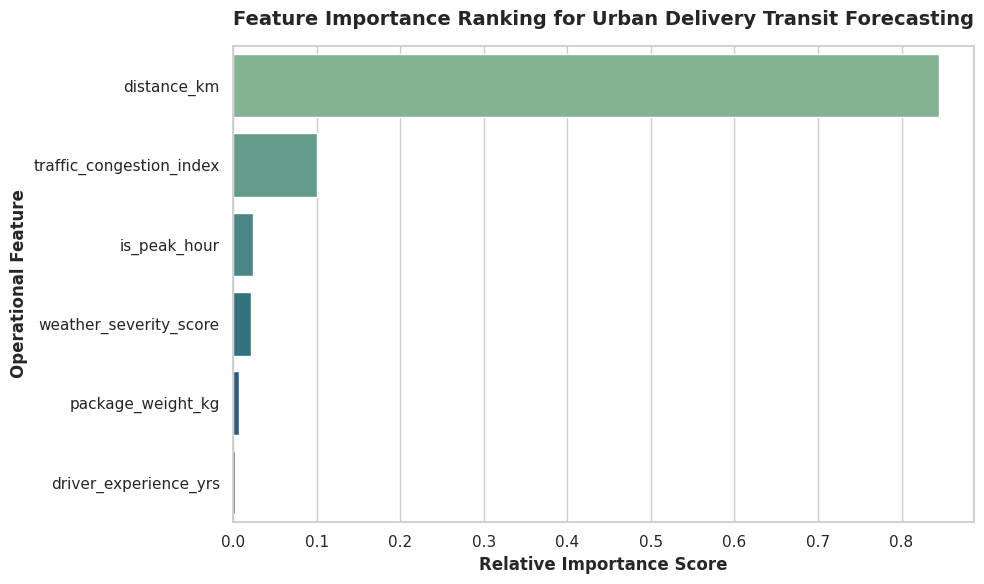

In [1]:
# ==============================================================================
# Task 4: ADVANCED PREDICTIVE MODELING & LOGISTICS OPTIMIZATION PIPELINE
# Logistics Supply Chain Analytics Internship Project
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set professional plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ------------------------------------------------------------------------------
# 1. ADVANCED DATA SIMULATION & FEATURE ENGINEERING
# ------------------------------------------------------------------------------
np.random.seed(42)
n_samples = 5000

print(f"Step 1: Generating simulated logistics dataset with {n_samples} records...")
df_model = pd.DataFrame({
    'order_id': range(40000, 40000 + n_samples),
    'distance_km': np.random.uniform(1.5, 55.0, n_samples),
    'package_weight_kg': np.random.uniform(0.2, 30.0, n_samples),
    'traffic_congestion_index': np.random.uniform(1.0, 5.0, n_samples), # 1: Free Flow, 5: Gridlock
    'driver_experience_yrs': np.random.randint(1, 10, n_samples),
    'is_peak_hour': np.random.choice([0, 1], size=n_samples, p=[0.65, 0.35]),
    'weather_severity_score': np.random.uniform(0.0, 3.0, n_samples)
})

# Constructing the target variable (Delivery Transit Time in Hours) using realistic logistics physics
df_model['delivery_time_hrs'] = (
    0.5 +
    (df_model['distance_km'] * 0.09) +
    (df_model['package_weight_kg'] * 0.015) +
    (df_model['traffic_congestion_index'] * 0.42) +
    (df_model['is_peak_hour'] * 0.55) +
    (df_model['weather_severity_score'] * 0.25) -
    (df_model['driver_experience_yrs'] * 0.02) +
    np.random.normal(0, 0.15, n_samples) # Add Gaussian noise
)

print(f"Dataset successfully created. Shape: {df_model.shape}")

# ------------------------------------------------------------------------------
# 2. FEATURE SELECTION & TRAIN-TEST DATA SPLITTING
# ------------------------------------------------------------------------------
print("\nStep 2: Preparing feature matrices and splitting data (80% train, 20% test)...")
feature_columns = [
    'distance_km', 'package_weight_kg', 'traffic_congestion_index',
    'driver_experience_yrs', 'is_peak_hour', 'weather_severity_score'
]

X = df_model[feature_columns]
y = df_model['delivery_time_hrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ------------------------------------------------------------------------------
# 3. HYPERPARAMETER TUNING VIA GRID SEARCH & CROSS-VALIDATION
# ------------------------------------------------------------------------------
print("\nStep 3: Initializing Random Forest with GridSearchCV hyperparameter tuning...")
base_rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"Optimal Hyperparameters Selected: {grid_search.best_params_}")

# ------------------------------------------------------------------------------
# 4. MODEL EVALUATION & VALIDATION METRICS
# ------------------------------------------------------------------------------
print("\nStep 4: Evaluating model performance on unseen test data...")
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("="*40)
print(f"FINAL MODEL PERFORMANCE EVALUATION:")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f} hours")
print(f"Mean Absolute Error (MAE)       : {mae:.4f} hours")
print(f"R-Squared ($R^2$) Score         : {r2:.4f} ({(r2*100):.2f}% variance explained)")
print("="*40)

# ------------------------------------------------------------------------------
# 5. FEATURE IMPORTANCE VISUALIZATION
# ------------------------------------------------------------------------------
print("\nStep 5: Extracting feature importances for operational optimization...")
importances = best_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='crest')
plt.title("Feature Importance Ranking for Urban Delivery Transit Forecasting", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Relative Importance Score", fontweight='bold')
plt.ylabel("Operational Feature", fontweight='bold')
plt.tight_layout()
plt.show()